# Hough Lines

### Import resources and display the image

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

In [2]:
IMG = '../../../img'

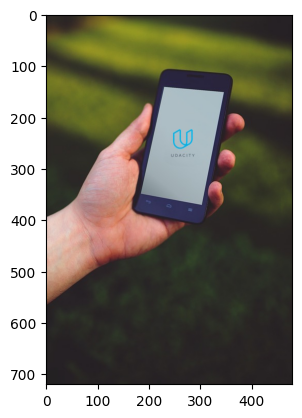

In [3]:
image = cv2.imread(f'{IMG}/phone.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image);

### Perform edge detection

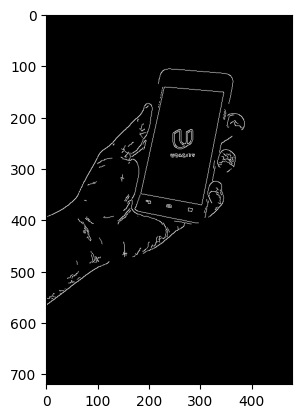

In [4]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
low_threshold = 50
high_threshold = 100
edges = cv2.Canny(gray, low_threshold, high_threshold)
plt.imshow(edges, cmap='gray');

### Find lines using a Hough transform

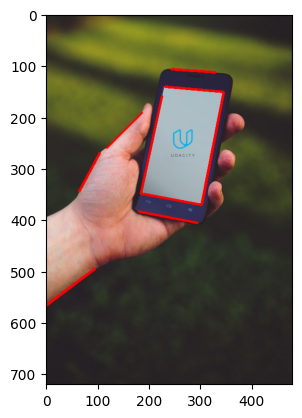

In [6]:
# Define the Hough transform parameters
rho = 1
theta = np.pi / 180
threshold = 60
min_line_length = 50
max_line_gap = 5

line_image = np.copy(image) #creating an image copy to draw lines on
# Run Hough on the edge-detected image
lines = cv2.HoughLinesP(
    edges, 
    rho, 
    theta, 
    threshold, 
    np.array([]), 
    min_line_length, 
    max_line_gap)
# Iterate over the output "lines" and draw lines on the image copy
RED = (255, 0, 0)
WIDTH = 3
for line in lines:
    for x1, y1, x2, y2 in line:
        cv2.line(line_image, (x1, y1), (x2, y2), RED, WIDTH)
plt.imshow(line_image);